In [1]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import GroupShuffleSplit, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, roc_auc_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             RocCurveDisplay)

from sklearn.calibration import CalibratedClassifierCV
from imblearn.over_sampling import SMOTE
import optuna
import shap
import matplotlib.pyplot as plt
import warnings, random

warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED); np.random.seed(SEED)

print("Libraries loaded")

Libraries loaded


In [2]:
# Feature engineering and data preparation
# ── Load ──────────────────────────────────────────────────────────────────────
from pathlib import Path

# 1. Load Data
DATA_PATH = Path("/kaggle/input/datasets/imelily/cleaned-dataset/physiopain/data") 
file_path = DATA_PATH / "cleaned_df.csv"
df = pd.read_csv(file_path)

# ── Engineer features ─────────────────────────────────────────────────────────
WINDOW = 64

df["acc_mag"]       = np.sqrt(df.acc_x**2 + df.acc_y**2 + df.acc_z**2)
df["eda_roll_mean"] = df.groupby("participant_id")["eda"].transform(
                          lambda x: x.rolling(WINDOW, min_periods=1).mean())
df["bvp_roll_std"]  = df.groupby("participant_id")["bvp"].transform(
                          lambda x: x.rolling(WINDOW, min_periods=1).std().fillna(0))
df["eda_diff"]      = df.groupby("participant_id")["eda"].transform(
                          lambda x: x.diff().fillna(0))
df["bvp_diff"]      = df.groupby("participant_id")["bvp"].transform(
                          lambda x: x.diff().fillna(0))

FEATURES = ["bvp", "eda", "acc_x", "acc_y", "acc_z", "temperature",
            "acc_mag", "eda_roll_mean", "bvp_roll_std", "eda_diff", "bvp_diff"]

# ── Binary target ─────────────────────────────────────────────────────────────
df["label"] = (df["pain_scale"] >= 4).astype(int)

X = df[FEATURES].values.astype(np.float32)
y = df["label"].values.astype(int)
groups = df["participant_id"].values

print(f"Class distribution: {np.bincount(y)}")
print(f"Features: {FEATURES}")

Class distribution: [337641 102873]
Features: ['bvp', 'eda', 'acc_x', 'acc_y', 'acc_z', 'temperature', 'acc_mag', 'eda_roll_mean', 'bvp_roll_std', 'eda_diff', 'bvp_diff']


In [3]:
# --- Group-aware, train/validation/test split
# Outer split: hold out 15% of participants as test
gss_outer = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
train_val_idx, test_idx = next(gss_outer.split(X, y, groups))

X_tv, y_tv = X[train_val_idx], y[train_val_idx]
g_tv       = groups[train_val_idx]
X_test, y_test = X[test_idx], y[test_idx]

# Inner split: carve out validation from train
gss_inner = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
train_idx, val_idx = next(gss_inner.split(X_tv, y_tv, g_tv))

X_train, y_train = X_tv[train_idx], y_tv[train_idx]
X_val,   y_val   = X_tv[val_idx],   y_tv[val_idx]

print(f"Train {len(X_train):,} | Val {len(X_val):,} | Test {len(X_test):,}")

Train 320,113 | Val 56,555 | Test 63,846


In [4]:
# Class imbalance handling
# using scale_pos_weight for XGBoost ───────────────────────
neg, pos  = np.bincount(y_train)
scale_pos = neg / pos          # weight minority class up
print(f"scale_pos_weight = {scale_pos:.2f}")

scale_pos_weight = 3.13


In [5]:
# Build and train XGBoost with early stopping
# ── DMatrix format
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=FEATURES)
dval   = xgb.DMatrix(X_val,   label=y_val,   feature_names=FEATURES)
dtest  = xgb.DMatrix(X_test,  label=y_test,  feature_names=FEATURES)

# ── Hyperparameters ───────────────────────────────────────────────────────────
params = {
    "objective":        "binary:logistic",
    "eval_metric":      ["logloss", "auc"],
    "max_depth":        6,
    "learning_rate":    0.05,
    "n_estimators":     1000,
    "subsample":        0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 5,
    "gamma":            0.1,
    "reg_alpha":        0.1,      # L1 regularisation
    "reg_lambda":       1.0,      # L2 regularisation
    "scale_pos_weight": scale_pos,
    "tree_method":      "hist",   # fast histogram method
    "seed":             SEED,
}

# ── Train with early stopping ─────────────────────────────────────────────────
evals_result = {}
model = xgb.train(
    params,
    dtrain,
    num_boost_round    = 1000,
    evals              = [(dtrain, "train"), (dval, "val")],
    early_stopping_rounds = 50,
    evals_result       = evals_result,
    verbose_eval       = 50,
)

print(f"\nBest iteration: {model.best_iteration}")
print(f"Best val AUC:   {model.best_score:.4f}")

[0]	train-logloss:0.65875	train-auc:0.95749	val-logloss:0.68584	val-auc:0.48904
[50]	train-logloss:0.13186	train-auc:0.99885	val-logloss:0.65851	val-auc:0.44626
[52]	train-logloss:0.12703	train-auc:0.99890	val-logloss:0.66324	val-auc:0.44567

Best iteration: 2
Best val AUC:   0.4941


              precision    recall  f1-score   support

    low_pain       0.71      0.77      0.74     48508
   high_pain       0.01      0.01      0.01     15338

    accuracy                           0.59     63846
   macro avg       0.36      0.39      0.38     63846
weighted avg       0.54      0.59      0.57     63846

ROC-AUC: 0.2708


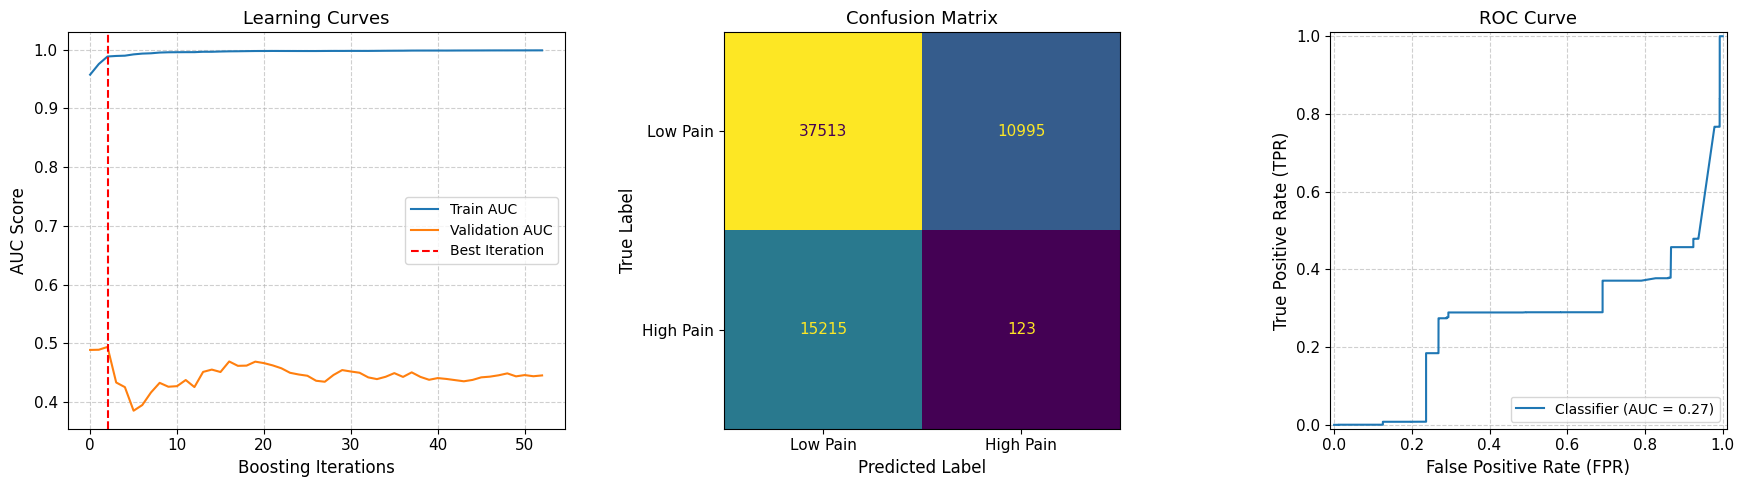

In [6]:
# Evaluation
# ── Predict ───────────────────────────────────────────────────────────────────
y_prob = model.predict(dtest, iteration_range=(0, model.best_iteration))
y_pred = (y_prob >= 0.5).astype(int)

print(classification_report(y_test, y_pred, target_names=["low_pain", "high_pain"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

# ── Plots ─────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay

# Optional: improve global readability
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "legend.fontsize": 10
})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── 1. Learning curves ─────────────────────────────────────────────
axes[0].plot(evals_result["train"]["auc"], label="Train AUC")
axes[0].plot(evals_result["val"]["auc"],   label="Validation AUC")
axes[0].axvline(model.best_iteration, color="red", linestyle="--", label="Best Iteration")

axes[0].set_title("Learning Curves")
axes[0].set_xlabel("Boosting Iterations")
axes[0].set_ylabel("AUC Score")
axes[0].grid(True, linestyle="--", alpha=0.6)
axes[0].legend()

# ── 2. Confusion matrix ────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Low Pain", "High Pain"]
)

disp.plot(ax=axes[1], colorbar=False)

axes[1].set_title("Confusion Matrix")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

# ── 3. ROC curve ───────────────────────────────────────────────────
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[2])

axes[2].set_title("ROC Curve")
axes[2].set_xlabel("False Positive Rate (FPR)")
axes[2].set_ylabel("True Positive Rate (TPR)")
axes[2].grid(True, linestyle="--", alpha=0.6)

# ── Layout & save ──────────────────────────────────────────────────
plt.tight_layout()
plt.savefig("xgb_evaluation.png", dpi=300, bbox_inches="tight")
plt.show()

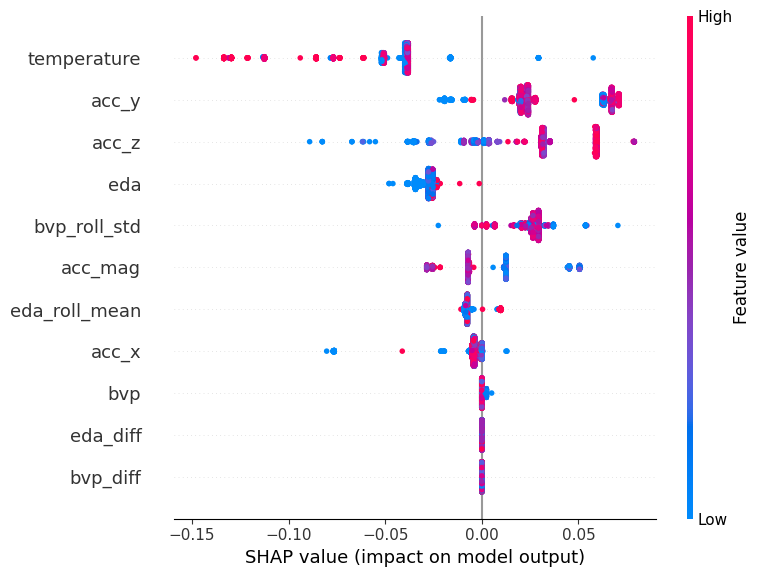

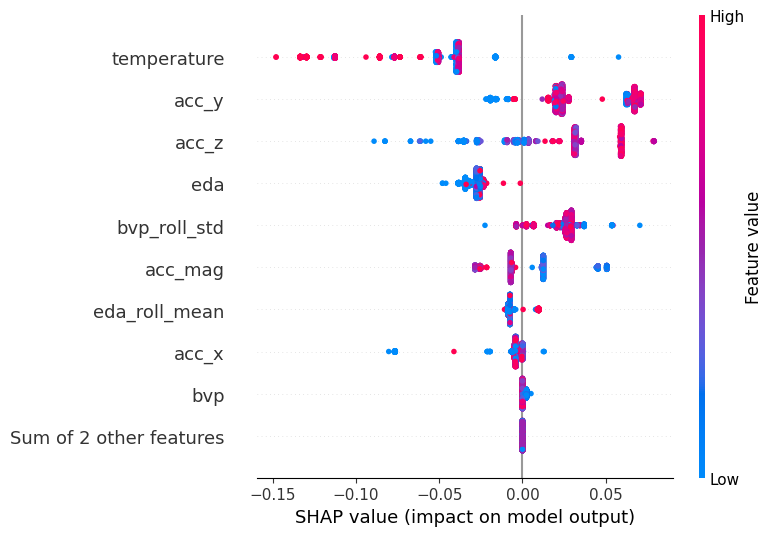

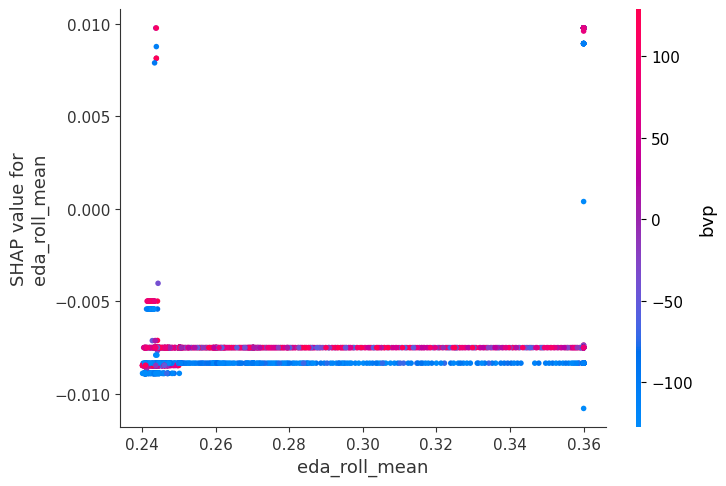

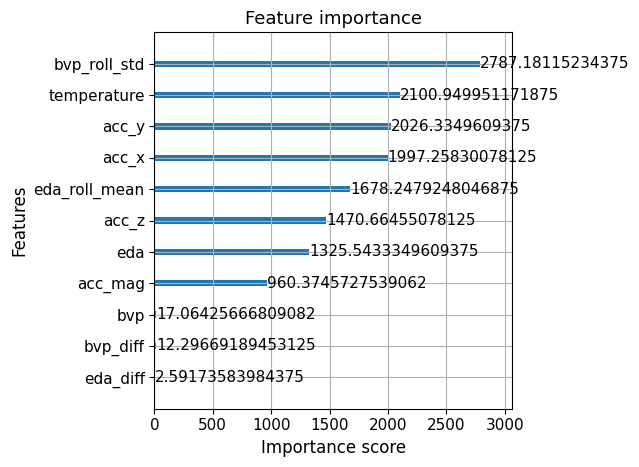

In [7]:
# Audit using SHAP feature importance
# ── SHAP TreeExplainer — native & fast for XGBoost ───────────────────────────
explainer  = shap.TreeExplainer(model)
shap_vals  = explainer.shap_values(X_test[:2000])    # sample for speed

# Summary plot — global importance
shap.summary_plot(shap_vals, X_test[:2000],
                  feature_names=FEATURES, show=False)
plt.tight_layout(); plt.savefig("shap_summary.png", dpi=150); plt.show()

# Beeswarm — shows direction of effect, not just magnitude
shap.plots.beeswarm(
    shap.Explanation(values=shap_vals,
                     data=X_test[:2000],
                     feature_names=FEATURES),
    show=False
)
plt.tight_layout(); plt.savefig("shap_beeswarm.png", dpi=150); plt.show()

# Dependence plot — how eda_roll_mean drives predictions
shap.dependence_plot("eda_roll_mean", shap_vals, X_test[:2000],
                     feature_names=FEATURES, show=False)
plt.tight_layout(); plt.savefig("shap_dependence.png", dpi=150); plt.show()

# Built-in XGBoost importance (cross-check)
xgb.plot_importance(model, importance_type="gain", max_num_features=11)
plt.tight_layout(); plt.savefig("xgb_importance.png", dpi=150); plt.show()

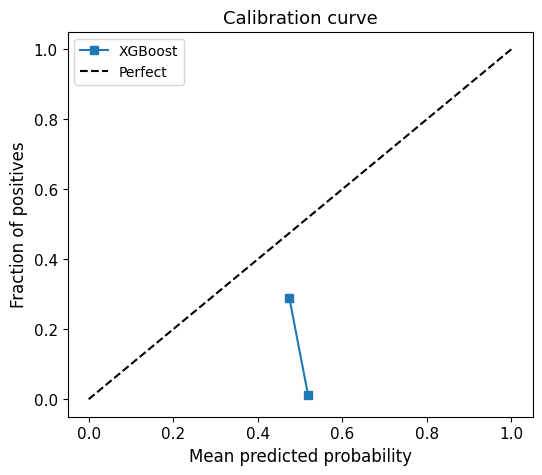

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:24:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:24:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:24:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:24:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

5-fold CV AUC: 0.6103 ± 0.1292


In [8]:
from sklearn.calibration import calibration_curve
# Validation using Calibration check
# ── Calibration curve ─────────────────────────────────────────────────────────
prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)

plt.figure(figsize=(6, 5))
plt.plot(prob_pred, prob_true, "s-", label="XGBoost")
plt.plot([0, 1], [0, 1], "k--", label="Perfect")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Calibration curve"); plt.legend()
plt.savefig("calibration.png", dpi=150); plt.show()

# ── Cross-validated AUC on train+val (stability check) ───────────────────────
xgb_cv = xgb.XGBClassifier(
    **{k: v for k, v in params.items() if k not in ["eval_metric", "n_estimators"]},
    n_estimators=model.best_iteration + 1,
    use_label_encoder=False,
    eval_metric="logloss",
)

cv_scores = cross_val_score(
    xgb_cv, X_tv, y_tv,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

print(f"5-fold CV AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

In [9]:
# Optimization using Optuna HPO
def objective(trial):
    p = {
        "objective":          "binary:logistic",
        "eval_metric":        "auc",
        "tree_method":        "hist",
        "seed":               SEED,
        "max_depth":          trial.suggest_int("max_depth", 3, 10),
        "learning_rate":      trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "subsample":          trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":   trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight":   trial.suggest_int("min_child_weight", 1, 20),
        "gamma":              trial.suggest_float("gamma", 0.0, 1.0),
        "reg_alpha":          trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda":         trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "scale_pos_weight":   scale_pos,
    }

    m = xgb.train(
        p, dtrain,
        num_boost_round       = 500,
        evals                 = [(dval, "val")],
        early_stopping_rounds = 30,
        verbose_eval          = False,
    )
    return m.best_score

study = optuna.create_study(direction="maximize",
                            sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=50, timeout=3600)

print("Best AUC:   ", study.best_value)
print("Best params:", study.best_params)

[I 2026-03-25 06:24:39,520] A new study created in memory with name: no-name-c27fabf5-000a-42ff-8fb0-9e2578e4c19b
[I 2026-03-25 06:24:40,245] Trial 0 finished with value: 0.5062385048688312 and parameters: {'max_depth': 5, 'learning_rate': 0.22648248189516848, 'subsample': 0.8659969709057025, 'colsample_bytree': 0.7993292420985183, 'min_child_weight': 4, 'gamma': 0.15599452033620265, 'reg_alpha': 0.00019517224641449495, 'reg_lambda': 2.1423021757741068}. Best is trial 0 with value: 0.5062385048688312.
[I 2026-03-25 06:24:40,962] Trial 1 finished with value: 0.5726075981402234 and parameters: {'max_depth': 7, 'learning_rate': 0.05675206026988748, 'subsample': 0.5102922471479012, 'colsample_bytree': 0.9849549260809971, 'min_child_weight': 17, 'gamma': 0.21233911067827616, 'reg_alpha': 0.0008111941985431928, 'reg_lambda': 0.0008260808399079611}. Best is trial 1 with value: 0.5726075981402234.
[I 2026-03-25 06:24:41,499] Trial 2 finished with value: 0.6494548433881675 and parameters: {'max

Best AUC:    0.7077742891490647
Best params: {'max_depth': 3, 'learning_rate': 0.02825396920624574, 'subsample': 0.8320213820152522, 'colsample_bytree': 0.8710814332296511, 'min_child_weight': 18, 'gamma': 0.16550571494582272, 'reg_alpha': 0.004580688954429568, 'reg_lambda': 0.0005839100047130885}


In [10]:
# Retrain best model on full train + val
best_p = {
    **study.best_params,
    "objective":        "binary:logistic",
    "eval_metric":      ["logloss", "auc"],
    "tree_method":      "hist",
    "scale_pos_weight": scale_pos,
    "seed":             SEED,
}

# Combine train + val for final training
X_full = np.vstack([X_train, X_val])
y_full = np.concatenate([y_train, y_val])
dfull  = xgb.DMatrix(X_full, label=y_full, feature_names=FEATURES)

final_model = xgb.train(
    best_p, dfull,
    num_boost_round = int(model.best_iteration * 1.1),   # slight boost since more data
    evals           = [(dtest, "test")],
    verbose_eval    = 50,
)

# ── Final test metrics ────────────────────────────────────────────────────────
y_prob_final = final_model.predict(dtest)
y_pred_final = (y_prob_final >= 0.5).astype(int)

print(f"\nFinal Test AUC: {roc_auc_score(y_test, y_prob_final):.4f}")
print(classification_report(y_test, y_pred_final,
                             target_names=["low_pain", "high_pain"]))

[0]	test-logloss:0.68078	test-auc:0.26369
[1]	test-logloss:0.68274	test-auc:0.27161

Final Test AUC: 0.2716
              precision    recall  f1-score   support

    low_pain       0.76      1.00      0.86     48508
   high_pain       0.14      0.00      0.00     15338

    accuracy                           0.76     63846
   macro avg       0.45      0.50      0.43     63846
weighted avg       0.61      0.76      0.66     63846



In [11]:
# Save report
import joblib

final_model.save_model("xgboost_pain.json")
joblib.dump({
    "features":    FEATURES,
    "best_params": study.best_params,
    "best_iter":   model.best_iteration,
    "scale_pos":   scale_pos,
}, "xgboost_pain_meta.pkl")

print("Saved → xgboost_pain.json + xgboost_pain_meta.pkl")

# ── Reload ────────────────────────────────────────────────────────────────────
loaded = xgb.Booster()
loaded.load_model("xgboost_pain.json")

Saved → xgboost_pain.json + xgboost_pain_meta.pkl
